In [2]:
import os
from pathlib import Path

from aiwhatif_cf.config import DicePipelineConfig

config = DicePipelineConfig()
print(config)

data dir path ok:         True
model dir path ok:        True
CF outputs dir path ok:   True
target_bp              : hltprhb
target_hc              : hltprhc
cf_output_dir          : /home/dyretna/Dokument/Code/GitHub/nightingale_projects/ai_counterfactuals_tests/cf_outputs
feature_cols           : ['etfruit', 'eatveg', 'cgtsmok', 'alcfreq', 'slprl', 'paccnois', 'bmi', 'gndr', 'dosprt']
immutable_cols         : ['gndr']
continuous_features    : ['bmi']
backend                : sklearn
model_type             : classifier
explainer_method       : random
stopping_threshold     : 0.5
posthoc_sparsity_param : 0.1
target_factor          : 0.5
cf_random_seed         : 111
train_data_path_bp     : /home/dyretna/Dokument/Code/GitHub/nightingale_projects/ai_counterfactuals_tests/data/05_single_target/ess_ready_v2_hltprhb_train.csv
train_data_path_hc     : /home/dyretna/Dokument/Code/GitHub/nightingale_projects/ai_counterfactuals_tests/data/05_single_target/ess_ready_v2_hltprhc_train.csv
test_da

# Loading Data

The distibution of train / test == 80 / 20.

We have three target on the same dataset:
- "hltprhb",
- "hltprhc",

In previous steps the distribution of all target classes has been stratifed
into the train / test .csv-files.

We will train a RandomforestClassifier for each target.
They are regarded as Outcome variables, and are not to be used as features when not targets, but are dropped in training.


In [3]:
import pandas as pd

train_df_hb = pd.read_csv(config.train_data_path_bp)
test_df_hb = pd.read_csv(config.test_data_path_bp)

train_df_hc = pd.read_csv(config.train_data_path_hc)
test_df_hc = pd.read_csv(config.test_data_path_hc)

In [4]:
train_df_hb

,etfruit,eatveg,cgtsmok,alcfreq,slprl,paccnois,bmi,gndr,dosprt,hltprhb
0,2.0,1.0,2.0,3.0,1.0,0,26.061679,1,2.0,0
1,3.0,4.0,6.0,2.0,2.0,0,30.864198,1,7.0,0
2,3.0,4.0,6.0,7.0,1.0,0,22.857143,1,7.0,0
3,2.0,3.0,6.0,6.0,2.0,0,26.672763,2,7.0,1
4,4.0,3.0,1.0,7.0,3.0,0,27.757487,1,4.0,0
...,...,...,...,...,...,...,...,...,...,...
32878,5.0,3.0,6.0,7.0,4.0,0,27.548209,2,7.0,0
32879,5.0,4.0,6.0,7.0,3.0,0,23.711845,2,1.0,0
32880,1.0,2.0,6.0,5.0,1.0,0,23.437500,2,0.0,0
32881,2.0,4.0,3.0,3.0,2.0,0,19.369835,1,7.0,0


The distribution on the classes for all three targets are as we can see very skewed.
below we can se that the distribution is the same on train and test data-files.

In [5]:
TARGET_BP = config.target_bp
TARGET_HC = config.target_hc

In [6]:
import matplotlib.pyplot as plt

def plot_target_distribution(train_df, test_df, target_col, label):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Train
    train_df[target_col].value_counts().plot(kind="bar", ax=axes[0])
    axes[0].set_title(f"Train data-set")
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Count")
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, ha="right")

    # Test
    test_df[target_col].value_counts().plot(kind="bar", ax=axes[1])
    axes[1].set_title(f"Test data-set")
    axes[1].set_xlabel("Class")
    axes[1].set_ylabel("Count")
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, ha="right")

    fig.suptitle(f"Distribution of {label} ({target_col})", fontsize=14)
    plt.tight_layout()
    plt.show()


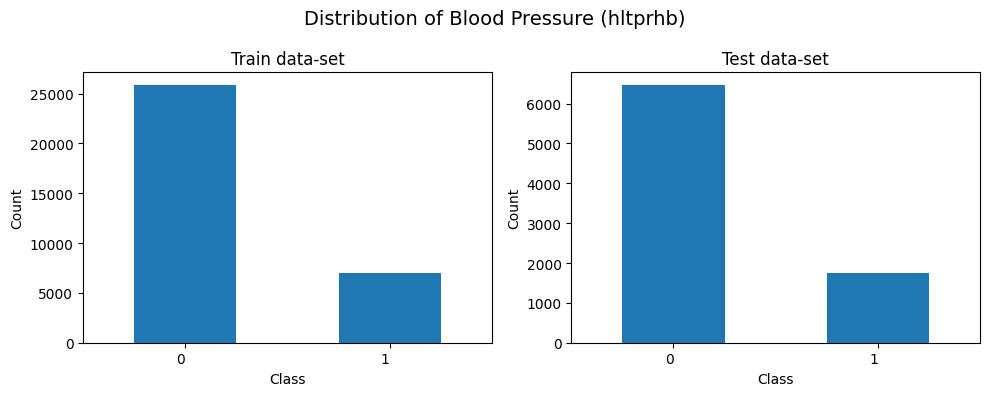

In [7]:
plot_target_distribution(train_df_hb, test_df_hb, TARGET_BP, label="Blood Pressure")

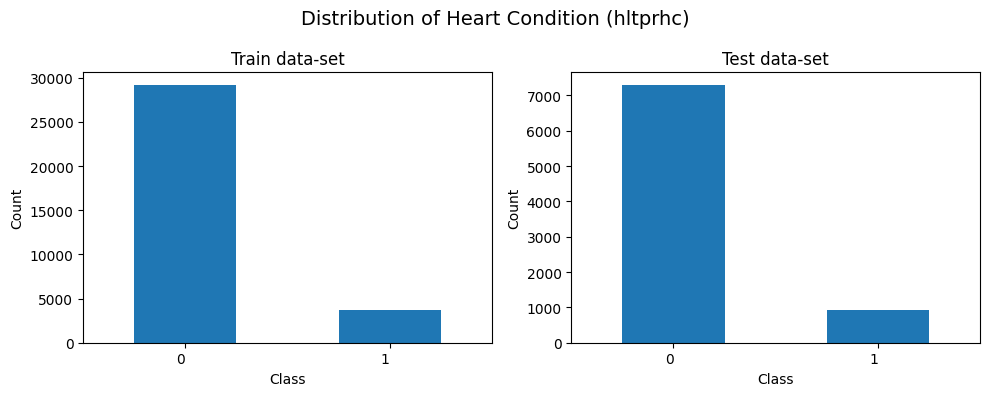

In [8]:
plot_target_distribution(train_df_hc, test_df_hc, TARGET_HC, label="Heart Condition")

# Loading and inspecting models

In [9]:
import joblib

current_bp_model = joblib.load(config.model_path_bp)
current_hc_model = joblib.load(config.model_path_hc)

In [10]:
X = config.feature_cols

# ---------------------------

y_train_bp = train_df_hb[config.target_bp]
X_train_bp = train_df_hb[X]

y_true_bp = test_df_hb[config.target_bp]
X_test_bp = test_df_hb[X]

# -------------------------

y_train_hc = train_df_hc[config.target_hc]
X_train_hc = train_df_hc[X]

y_true_hc = test_df_hc[config.target_hc]
X_test_hc = test_df_hc[X]

In [11]:
y_pred_bp = current_bp_model.predict(X_test_bp)
y_pred_hc = current_hc_model.predict(X_test_hc)

In [12]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

print(classification_report(y_true_bp, y_pred_bp))
print()
print("Roc Score auc score: ", roc_auc_score(y_true_bp, y_pred_bp), "\n")

              precision    recall  f1-score   support

           0       0.82      0.99      0.90      6461
           1       0.86      0.21      0.34      1760

    accuracy                           0.82      8221
   macro avg       0.84      0.60      0.62      8221
weighted avg       0.83      0.82      0.78      8221


Roc Score auc score:  0.6006770957915324 



In [14]:
print(classification_report(y_true_hc, y_pred_hc))
print()
print("Roc Score auc score: ", roc_auc_score(y_true_hc, y_pred_hc), "\n")

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      7288
           1       0.83      0.02      0.03       933

    accuracy                           0.89      8221
   macro avg       0.86      0.51      0.49      8221
weighted avg       0.88      0.89      0.84      8221


Roc Score auc score:  0.5078327674263469 



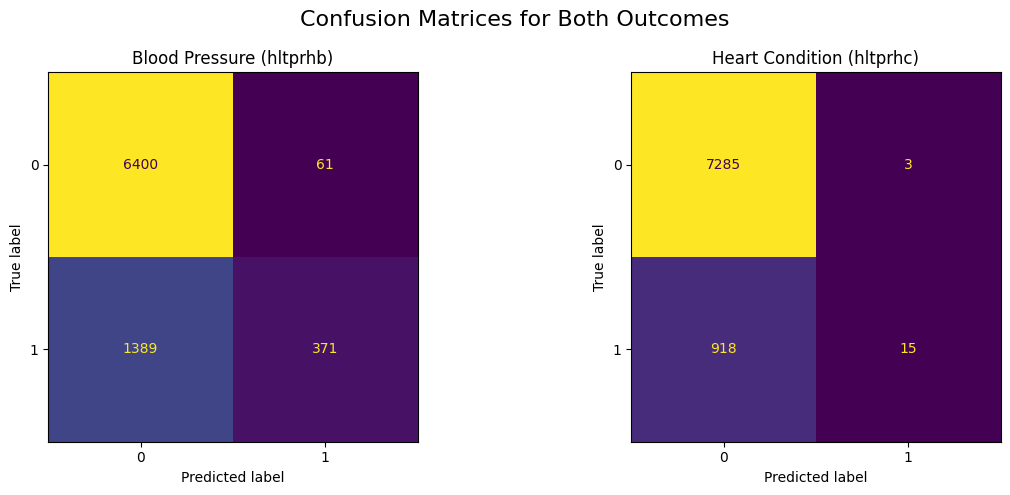

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Blood pressure (HB)
disp_hb = ConfusionMatrixDisplay.from_predictions(
    y_true_bp,
    y_pred_bp,
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title(f"Blood Pressure ({TARGET_BP})")

# Health complaints (HC)
disp_hc = ConfusionMatrixDisplay.from_predictions(
    y_true_hc,
    y_pred_hc,
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title(f"Heart Condition ({TARGET_HC})")

# Suptitle
fig.suptitle("Confusion Matrices for Both Outcomes", fontsize=16)

plt.tight_layout()
plt.show()


# testing gridsearch with bloodpressure dataset

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


pipeline = Pipeline(
    [
        ("rf", RandomForestClassifier())
    ]
)

param_dist = {
    "rf__n_estimators":     [300, 500, 800],
    "rf__max_depth":        [4,5,8,10,20],
    "rf__min_samples_split":[2,5,10],
    "rf__min_samples_leaf": [1,2,4],
    "rf__max_features":     ["sqrt","log2", None],
    "rf__bootstrap":        [True],
    "rf__class_weight":     ["balanced","balanced_subsample"],
}

rand = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=200,
    scoring="recall_macro",
    n_jobs=-1,
    cv=5,
    verbose=2,
    random_state=42,
)
rand.fit(X_train_bp, y_train_bp)


print("RandomizedSearch Done. best score (cv):", rand.best_score_)
print("Best parameters:")
print(rand.best_params_)


Fitting 5 folds for each of 200 candidates, totalling 1000 fits


[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=500; total time=   8.7s
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=500; total time=   8.9s
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=500; total time=   9.0s
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=500; total time=   9.1s
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_depth=10, rf__max_features=sqrt, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=500; total time=   9.3s
[CV] END rf__bootstrap=True, rf__class_weight=balanced_subsample,

/home/dyretna/.pyenv/versions/CF_new/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_depth=20, rf__max_features=None, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=800; total time=  46.3s
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_depth=20, rf__max_features=None, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=800; total time=  47.7s
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_depth=20, rf__max_features=log2, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=800; total time=  22.1s
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_depth=20, rf__max_features=log2, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=800; total time=  21.4s
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_depth=20, rf__max_features=log2, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=800; total time=  21.7s
[CV] END rf__bootstrap=True, rf__class_weight=balanced, rf__max_d

In [34]:
import pandas as pd

res = pd.DataFrame(rand.cv_results_)

top_estimators = (
    res
    .sort_values("mean_test_score", ascending=False)
    .head(20)
)

top_estimators = top_estimators.drop(columns=[c for c in top_estimators.columns if c.startswith("param_")])
params = top_estimators["params"].apply(pd.Series)

top_estimators = pd.concat([top_estimators.drop(columns=["params"]), params], axis=1)

top_estimators


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,rf__n_estimators,rf__min_samples_split,rf__min_samples_leaf,rf__max_features,rf__max_depth,rf__class_weight,rf__bootstrap
6,4.535508,0.171804,0.152035,0.036699,0.659265,0.659691,0.658986,0.648746,0.655915,0.656521,0.004110,1,300,2,2,log2,8,balanced,True
125,16.900675,0.377999,0.369904,0.053144,0.658299,0.656496,0.658987,0.648554,0.658918,0.656251,0.003952,2,800,2,4,sqrt,8,balanced_subsample,True
28,11.784009,0.315276,0.320180,0.005948,0.657009,0.657368,0.658017,0.648069,0.660725,0.656237,0.004287,3,800,2,4,log2,8,balanced,True
9,16.173645,0.329711,0.344790,0.030585,0.656619,0.654234,0.659953,0.648778,0.660143,0.655946,0.004205,4,800,2,1,sqrt,8,balanced_subsample,True
192,7.607763,0.123779,0.217324,0.015824,0.659750,0.656978,0.656403,0.649133,0.657271,0.655907,0.003575,5,500,10,1,log2,8,balanced,True
110,16.594951,0.096854,0.355406,0.014752,0.658138,0.657592,0.658372,0.648586,0.656496,0.655837,0.003683,6,800,5,2,log2,8,balanced_subsample,True
76,10.103334,0.220523,0.207610,0.010016,0.658783,0.655236,0.658177,0.646971,0.659821,0.655798,0.004669,7,500,5,1,log2,8,balanced_subsample,True
98,10.722233,0.271510,0.217695,0.013234,0.656556,0.658078,0.657178,0.648424,0.658013,0.655650,0.003656,8,500,2,4,log2,8,balanced_subsample,True
99,12.782419,0.237319,0.393782,0.035208,0.657266,0.657013,0.657275,0.649392,0.657238,0.655637,0.003124,9,800,5,4,log2,8,balanced,True
80,4.302697,0.044979,0.130029,0.008859,0.658105,0.655205,0.659373,0.647231,0.657982,0.655579,0.004390,10,300,5,4,log2,8,balanced,True


In [ ]:
best_rf = rand.best_estimator_
best_rf_pred = best_rf.predict(X_test_bp)

In [36]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
print(classification_report(y_true_bp, best_rf_pred))
print()
print("Roc Score auc score: ", roc_auc_score(y_true_bp, best_rf_pred), "\n")

              precision    recall  f1-score   support

           0       0.87      0.64      0.74      6461
           1       0.33      0.66      0.44      1760

    accuracy                           0.64      8221
   macro avg       0.60      0.65      0.59      8221
weighted avg       0.76      0.64      0.67      8221


Roc Score auc score:  0.6489507411602483 



Text(0.5, 1.0, "Best 'Randomized Search' rf-model on blood-pressure")

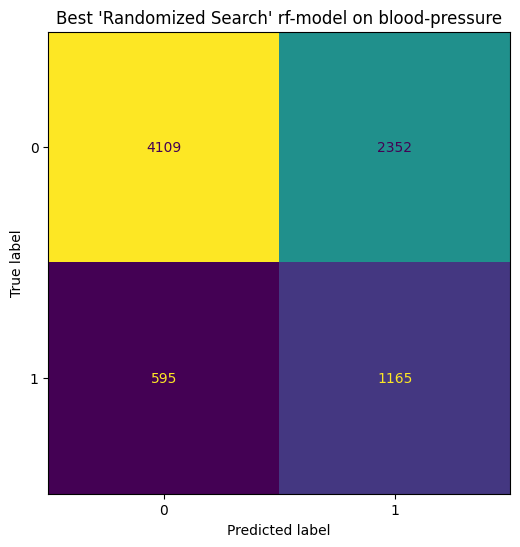

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_true_bp,
    best_rf_pred,
    ax=ax,
    colorbar=False,
    )

ax.set_title("Best 'Randomized Search' rf-model on blood-pressure")

# Analysis

When training machine‑learning classifiers on imbalanced datasets, it is common to observe a systematic shift in error patterns depending on the choice of class weighting. In the unweighted case, models tend to minimize overall error by favoring the majority class, which typically results in high false‑negative rates for the minority class. This occurs because misclassifying minority‑class samples has little impact on the loss function when the majority class dominates the data distribution.

Applying class weights—such as class_weight="balanced" or class_weight="balanced_subsample"—alters the effective loss landscape by increasing the penalty for misclassifying minority‑class samples. The model is therefore encouraged to prioritize sensitivity (recall) for the minority class. A well‑known consequence of this reweighting is a shift in the decision boundary toward the minority class. As a result, the classifier becomes more likely to label ambiguous samples as belonging to the minority class. This reduces false negatives but simultaneously increases false positives.

This phenomenon is not specific to a particular algorithm. It appears across a wide range of models, including Random Forests, Complement Naive Bayes, and other probabilistic or ensemble methods. The underlying mechanism is the same: class weighting modifies the optimization objective so that the model trades precision for recall in the minority class. When the dataset is strongly imbalanced, this tradeoff becomes especially pronounced, and the model may converge to a region of the parameter space where improvements in recall necessarily come at the cost of increased false‑positive rates.

In the experiments above, Random Forest performance plateaued across a broad hyperparameter search, with mean macro‑recall values varying only marginally. This indicates that the model has reached its performance ceiling under the current data distribution and feature representation. Further hyperparameter tuning is unlikely to yield substantial improvements. Instead, adjustments to the decision threshold, probability calibration, or the use of alternative model families (e.g., gradient‑boosted trees) may be required to achieve a more favorable balance between false positives and false negatives.